In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.signal import fftconvolve
from skimage import io, img_as_float
from skimage.restoration import richardson_lucy, wiener, unsupervised_wiener, denoise_tv_chambolle

In [8]:
def load_image(path):
    """Load an image from the given path."""
    return img_as_float(io.imread(path, as_gray=True))


def crop_psf_from_full_image(psf_full, crop_size=101, center=None):
    """Crop a PSF from a larger PSF image without interpolation.

    This keeps pixel values unchanged (no resizing) and centers the crop on the
    PSF peak (unless a center is explicitly provided).

    Args:
        psf_full: 2D numpy array containing the full PSF image.
        crop_size: odd integer size of the square crop.
        center: Optional (y, x) tuple for the crop center.

    Returns:
        Cropped and normalized PSF.
    """

    if center is None:
        center = np.unravel_index(np.argmax(psf_full), psf_full.shape)

    half = crop_size // 2
    y, x = center

    # Pad if the crop window would exceed the image boundaries.
    pad_y = max(0, half - y, (y + half) - (psf_full.shape[0] - 1))
    pad_x = max(0, half - x, (x + half) - (psf_full.shape[1] - 1))

    if pad_y > 0 or pad_x > 0:
        psf_full = np.pad(psf_full, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant')
        y += pad_y
        x += pad_x

    cropped = psf_full[y - half : y + half + 1, x - half : x + half + 1]
    cropped = cropped.astype(np.float64)

    # Normalize so that sum(psf) == 1 (energy conservation)
    cropped /= np.sum(cropped)

    return cropped


def lucy_richardson_deconvolution(lr_image, psf, iterations=30, clip=True):
    """Perform Lucy-Richardson deconvolution."""
    return richardson_lucy(lr_image, psf, iterations, clip=clip)


def wiener_deconvolution(lr_image, psf, balance=0.01, clip=True):
    """Perform Wiener deconvolution.

    balance controls the noise/regularization tradeoff. Smaller values preserve more
    high-frequency detail but amplify noise.
    """

    deconv = wiener(lr_image, psf, balance=balance, clip=clip)
    return deconv


def tv_regularized_rl(lr_image, psf, iterations=30, weight=0.01, clip=True):
    """TV-regularized Richardson-Lucy (denoise + RL)."""

    # Apply a small amount of TV denoising before RL to stabilize high frequencies.
    denoised = denoise_tv_chambolle(lr_image, weight=weight)
    return richardson_lucy(denoised, psf, iterations, clip=clip)

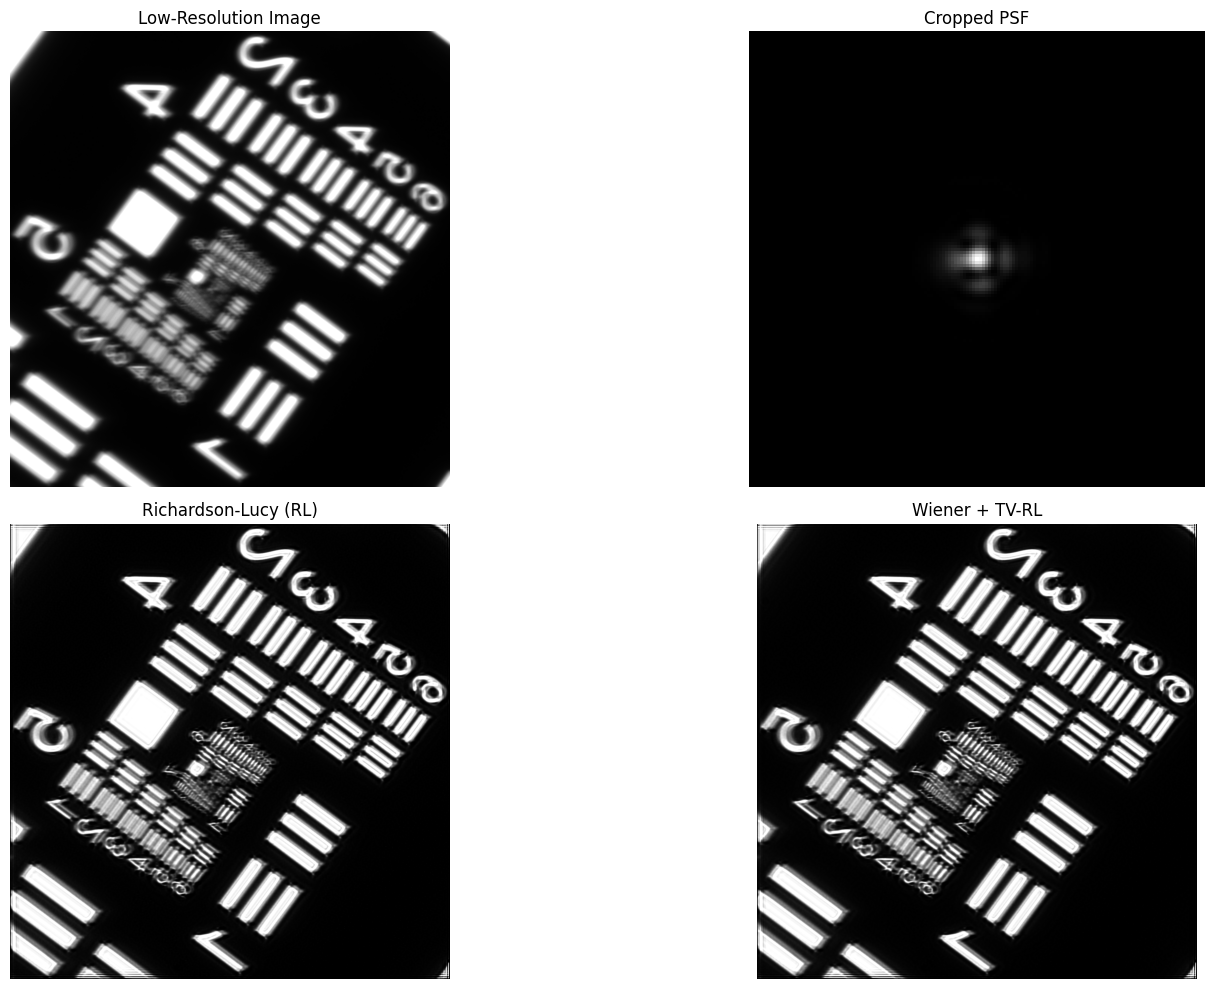

In [ ]:
def main():
    # Paths to the images
    lr_image_path = './original_image.png'
    psf_path = './psf_kernel.png'

    # Load images
    lr_image = load_image(lr_image_path)

    # Load the full PSF image and crop around the peak (no interpolation)
    psf_full = load_image(psf_path)
    psf = crop_psf_from_full_image(psf_full, crop_size=151)

    # Perform deconvolution using several methods
    rl_image = lucy_richardson_deconvolution(lr_image, psf, iterations=200)
    tv_rl_image = tv_regularized_rl(lr_image, psf, iterations=200, weight=0.0001)

    # Plot results
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 2, 1)
    plt.title("Low-Resolution Image")
    plt.imshow(lr_image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title("Cropped PSF")
    plt.imshow(psf, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.title("Richardson-Lucy (RL)")
    plt.imshow(rl_image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title("Wiener + TV-RL")
    plt.imshow(tv_rl_image, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()